<a href="https://colab.research.google.com/github/MarioDLCruz/PolisemiaV1/blob/main/umapv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

Conectar con google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cargar el csv con la tabla de tokens y sus embeddings

In [3]:
file_path = '/content/drive/MyDrive/tokens1k.csv'
df = pd.read_csv(file_path)

In [ ]:
df

,token,id_tweet,region,id_vector,vector
0,[CLS],0,Jalisco,0,[ 1.32701714e-02 -1.79053750e-02 -6.18814072e-...
1,Jalisco,0,Jalisco,1,[ 4.20953473e-03 -3.29080522e-02 1.30279278e-...
2,_GEO,0,Jalisco,2,[-1.35559319e-02 -1.35187013e-03 1.71045307e-...
3,_USR,0,Jalisco,3,[-3.58271115e-02 -4.46212329e-02 2.43038628e-...
4,Se,0,Jalisco,4,[ 2.86497883e-02 -2.64977496e-02 1.78820007e-...
...,...,...,...,...,...
30348,##I,999,Mexico_City,19,[ 9.51175019e-03 7.65987625e-03 7.00742528e-...
30349,##f,999,Mexico_City,20,[-6.96010841e-03 -2.21082475e-02 6.97800005e-...
30350,😭,999,Mexico_City,21,[-5.22314981e-02 -7.29229525e-02 -2.57079042e-...
30351,_URL,999,Mexico_City,22,[-1.76484715e-02 -9.14828330e-02 -3.17632803e-...


In [ ]:
reducer = umap.UMAP()

Cambiar campo vector a float

In [4]:
import numpy as np
import re

def parse_vector(v_str):
    # Elimina los corchetes si existen y divide por espacios
    clean_str = re.sub(r'[\[\]]', '', v_str)
    # Convierte en lista de floats
    return np.fromstring(clean_str, sep=' ')

# Aplica la conversión
df['vector'] = df['vector'].apply(parse_vector)


Normalizando vectores, modificando n_neighbors


In [17]:
from sklearn.preprocessing import StandardScaler
import umap

X = np.vstack(df['vector'].values)
X/=np.linalg.norm(X, axis=1).reshape(-1, 1)
X.shape
embedding = umap.UMAP(metric="cosine", n_neighbors=3).fit_transform(X)


In [ ]:
np.linalg.norm(X[0])

np.float64(1.0)

In [ ]:
X.shape

(30353, 512)

In [ ]:
embedding.shape

(30353, 2)

In [6]:
import matplotlib.pyplot as plt

Grafica de Proyección UMAP de vectores de tokens por región

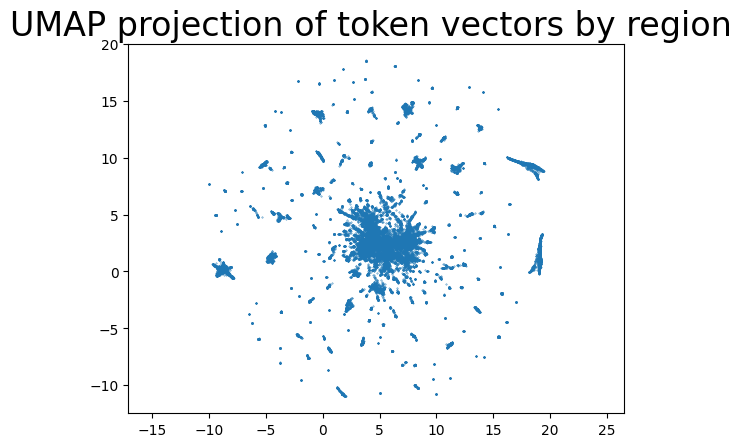

In [ ]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=.1,
    )

    #c=[palette[i] for i in region_indices])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of token vectors by region ', fontsize=24);

In [18]:
df["x"] = embedding[:, 0]
df["y"] = embedding[:, 1]
df[["token", "region", "x", "y"]]


,token,region,x,y
0,[CLS],Jalisco,-5.030239,11.368506
1,Jalisco,Jalisco,-8.427827,0.649946
2,_GEO,Jalisco,-1.511494,9.251248
3,_USR,Jalisco,10.607595,5.600357
4,Se,Jalisco,3.172905,9.814754
...,...,...,...,...
30348,##I,Mexico_City,-6.897099,-6.500303
30349,##f,Mexico_City,4.935370,-1.570055
30350,😭,Mexico_City,7.449572,-8.786512
30351,_URL,Mexico_City,-2.670933,-0.113724


In [19]:
import plotly.express as px
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="region",
    hover_data=["token", "region", "id_tweet"],
    title="UMAP projection of token vectors by region",
    width=1000,
    height=700
)


fig.update_traces(marker=dict(size=3, opacity=0.6), selector=dict(mode='markers'))
fig.update_layout(legend_title="Región", title_x=0.5)

fig.show()


In [ ]:
from google.colab import files
fig.write_html("umap_tokens.html")
files.download("umap_tokens.html")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Graficacion en 3D

In [ ]:

reducer3d = umap.UMAP(n_components=3, metric="cosine")
embedding_3d = reducer3d.fit_transform(X)

# Guardamos las nuevas dimensiones
df["x"] = embedding_3d[:, 0]
df["y"] = embedding_3d[:, 1]
df["z"] = embedding_3d[:, 2]


In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="x",
    y="y",
    z="z",
    color="region",  # O puedes usar "cluster"
    hover_data=["token"],
    opacity=0.6
)
fig.update_traces(marker=dict(size=1))
fig.update_layout(title="UMAP 3D projection of token vectors")
fig.show()
fig.write_html("umap_3d.html")


In [ ]:
from google.colab import files
files.download("umap_3d.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-15-2172382678.py:6: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



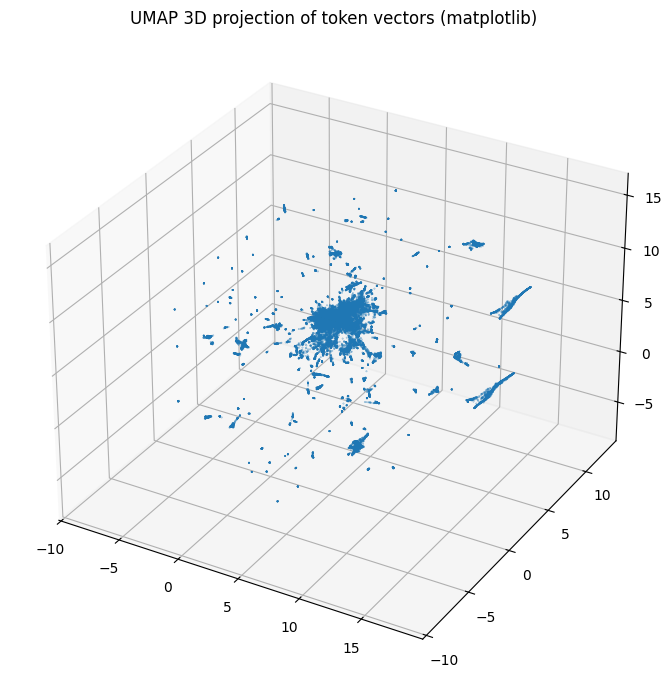

In [ ]:

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df["x"],
    df["y"],
    df["z"],

    cmap="tab20",
    s=.1,
    alpha=0.6
)

ax.set_title("UMAP 3D projection of token vectors (matplotlib)")
plt.tight_layout()
plt.show()


Graficacion con k-means prueba 1

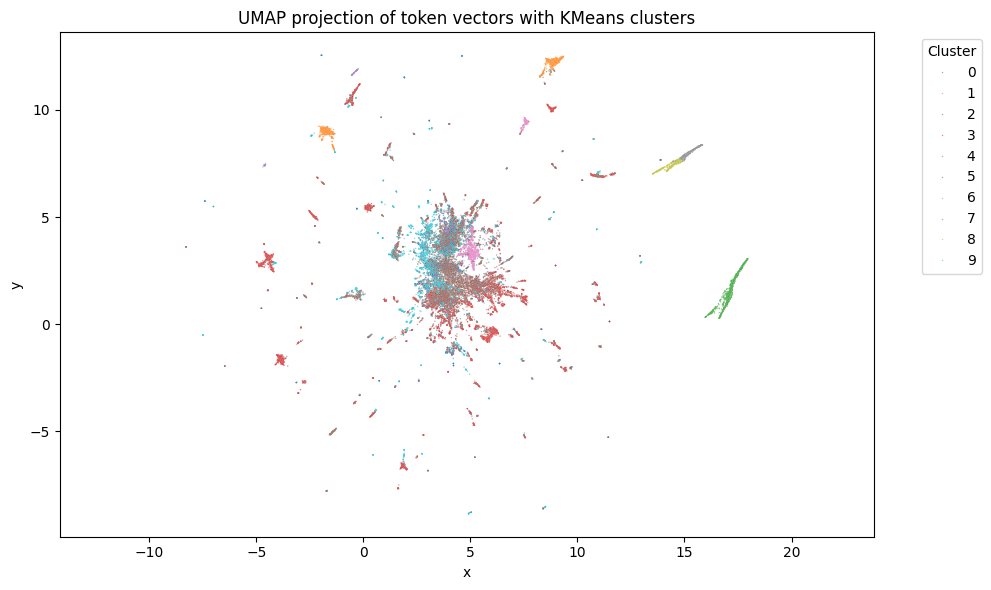

In [ ]:

from sklearn.cluster import KMeans
import seaborn as sns


# Aplicar KMeans
kmeans = KMeans(n_clusters=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Visualizar sobre UMAP
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df["x"],
    y=df["y"],
    hue=df["cluster"],
    palette="tab10",
    s=1,
    alpha=0.6,
    legend="full"
)
plt.title("UMAP projection of token vectors with KMeans clusters")
plt.gca().set_aspect("equal", "datalim")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Clusterización con DBSCAN

In [10]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons, make_circles, make_classification, make_s_curve

In [111]:

from sklearn.preprocessing import StandardScaler

X_umap = df[["x", "y"]].values

eps = 0.1
db = DBSCAN(eps=eps, min_samples=7)
df["dbscan_cluster"] = db.fit_predict(X_umap)



In [156]:
np.unique(np.array(df["dbscan_cluster"].to_list()),return_counts=True)

(array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,
         12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,
         25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
         38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,
         51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,
         64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,
         77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,
         90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
        103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
        116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128,
        129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141,
        142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
        155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
        168, 169, 170, 171, 172, 173, 174, 175, 176

In [113]:
import plotly.express as px
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="dbscan_cluster",
    title="DBSCAN clustering sobre embeddings (UMAP 2D)",
    opacity=0.7,
    hover_data=["token","region","id_tweet"]
)
fig.update_traces(marker=dict(size=2))
fig.update_layout(height=600)
fig.show()

In [122]:
print("Número de Cústeres:", df["dbscan_cluster"].nunique())


Número de Cústeres: 906


Lista de en cuantas regiones aparece un token excluyendo anomalias(cluster -1)

In [148]:

df_filtrado = df[df["dbscan_cluster"] != -1]


regiones_por_token = (
    df_filtrado.groupby("token")["region"]
    .nunique()
    .reset_index(name="num_regiones")
    .sort_values(by="num_regiones", ascending=True)
)


regiones_por_token


,token,num_regiones
20,"##""",1
25,##....,1
10,""",",1
12,"""...",1
13,""":",1
...,...,...
1542,",",31
2506,_GEO,32
2505,[SEP],32
2504,[CLS],32


Lista de numero de token por cluster excluyendo anomalias (cluster -1)

In [149]:

tokens_por_cluster = (
    df_filtrado.groupby("dbscan_cluster")["token"]
    .count()
    .reset_index(name="num_tokens")
    .sort_values(by="num_tokens", ascending=True)
)


tokens_por_cluster


,dbscan_cluster,num_tokens
900,900,6
458,458,6
858,858,6
904,904,7
898,898,7
...,...,...
0,0,296
22,22,322
13,13,504
24,24,589


In [153]:

df_filtrado = df[df["dbscan_cluster"] != -1]


tokens_por_cluster = (
    df_filtrado.groupby("dbscan_cluster")["token"]
    .count()
    .reset_index(name="num_tokens")
)


regiones_por_cluster = (
    df_filtrado.groupby("dbscan_cluster")["region"]
    .nunique()
    .reset_index(name="num_regiones")
)

resumen_cluster = pd.merge(tokens_por_cluster, regiones_por_cluster, on="dbscan_cluster")

resumen_cluster = resumen_cluster.sort_values(by="num_tokens")
resumen_cluster = resumen_cluster.sort_values(by="num_regiones", ascending=True)
resumen_cluster


,dbscan_cluster,num_tokens,num_regiones
341,341,7,1
902,902,11,1
811,811,7,1
565,565,7,1
1,1,72,1
...,...,...,...
10,10,274,30
58,58,109,31
109,109,224,31
24,24,589,32


Lista de cuantos cluster tiene cada region

In [134]:

clusters_por_region = (
    df.groupby("region")["dbscan_cluster"]
    .nunique()
    .reset_index(name="num_clusters_unicos")
    .sort_values(by="num_clusters_unicos", ascending=False)
)

clusters_por_region


,region,num_clusters_unicos
14,Mexico_City,796
17,NL,638
12,Jalisco,569
1,BC,533
13,Mexico,505
25,Sonora,445
29,Veracruz,393
5,Chihuahua,357
24,Sinaloa,345
9,Guanajuato,309


Lista de todos los tokens y en que cluster se encuentra

In [155]:
tabla_tokens = df[["token", "region", "dbscan_cluster"]].sort_values( by=["token","dbscan_cluster"])
excel_filename = f"tabla_tokens.xlsx"
tabla_tokens.to_excel(excel_filename, index=False)
tabla_tokens

,token,region,dbscan_cluster
4508,!,Mexico_City,-1
22413,!,Guanajuato,-1
28110,!,BCS,-1
416,!,NL,201
1839,!,Mexico_City,201
...,...,...,...
2936,🦠,Zacatecas,56
10641,🧐,Tabasco,460
14259,🧡,Sonora,779
25422,🩹,QR,56


Mostrar cluster en especifico

In [154]:

cluster_id = 341
tokens_cluster = df[df["dbscan_cluster"] == cluster_id][["token", "region", "dbscan_cluster"]]

tokens_cluster = tokens_cluster.sort_values(by="token")

tokens_cluster


,token,region,dbscan_cluster
985,Querétaro,Querétaro,341
4190,Querétaro,Querétaro,341
5984,Querétaro,Querétaro,341
7665,Querétaro,Querétaro,341
20184,Querétaro,Querétaro,341
20205,Querétaro,Querétaro,341
22813,Querétaro,Querétaro,341


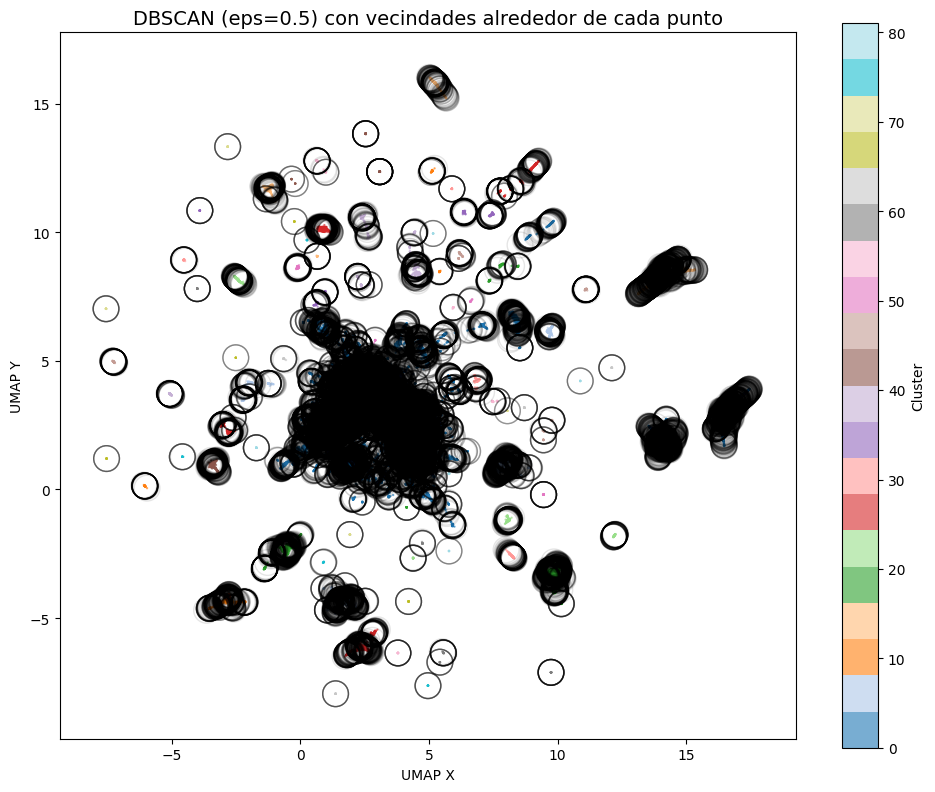

In [ ]:
plt.figure(figsize=(10, 8))

# Puntos coloreados por clúster
scatter = plt.scatter(
    df["x"], df["y"],
    c=df["dbscan_cluster"],
    cmap="tab20",
    s=.5,
    alpha=0.6
)

# Dibujar un círculo eps alrededor de cada punto
for x, y in X_umap:
    circle = plt.Circle((x, y), eps, color='black', fill=False, alpha=0.1)
    plt.gca().add_patch(circle)

plt.gca().set_aspect("equal", "box")
plt.title(f"DBSCAN (eps={eps}) con vecindades alrededor de cada punto", fontsize=14)
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()



Clusterización con HDBSCAN

In [157]:
from sklearn.cluster import HDBSCAN
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons, make_circles, make_classification, make_s_curve

In [166]:
clusterer = HDBSCAN(min_cluster_size=9)
cluster_labels = clusterer.fit_predict(X_umap)

df["hdbscan_cluster"] = cluster_labels

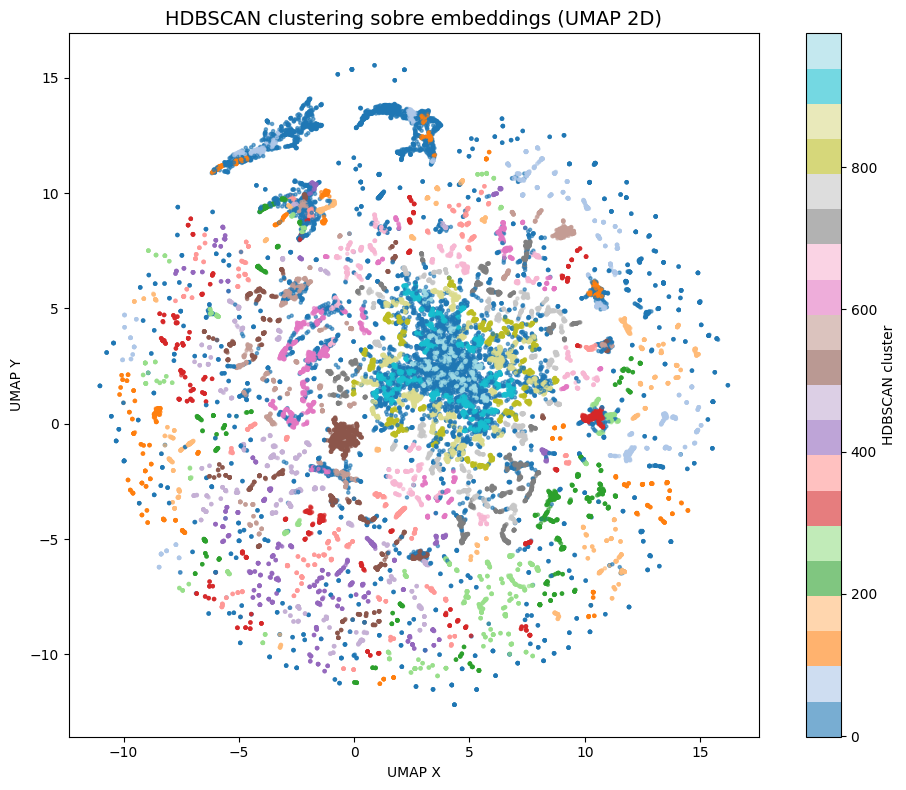

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df["x"],
    df["y"],
    c=df["hdbscan_cluster"],
    cmap="tab20",
    s=5,
    alpha=0.6
)
plt.colorbar(scatter, label="HDBSCAN cluster")
plt.title("HDBSCAN clustering sobre embeddings (UMAP 2D)", fontsize=14)
plt.xlabel("UMAP X")
plt.ylabel("UMAP Y")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()


In [168]:
print("Número de Cústeres:", df["hdbscan_cluster"].nunique())


Número de Cústeres: 990


In [169]:
import plotly.express as px

fig = px.scatter(
    df,
    x="x",
    y="y",
    color="hdbscan_cluster",
    title="Clustering con HDBSCAN sobre embeddings (UMAP 2D)",
    opacity=0.7,
    hover_data=["token", "region","id_tweet"]
)

fig.update_traces(marker=dict(size=3))
fig.update_layout(height=600)
fig.show()
